In [12]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V2_Weights
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [14]:
normalize = transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225]
)

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])

In [15]:
test_dir = "../Dataset/Test"

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

class_names = test_dataset.classes

print(class_names)
print("Total Test Images:", len(test_dataset))

['Damaged', 'Good', 'Rusty']
Total Test Images: 37


In [16]:
num_classes = len(class_names)

from torchvision.models import MobileNet_V2_Weights

model = models.mobilenet_v2(
    weights=MobileNet_V2_Weights.DEFAULT
)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(
    model.last_channel,
    num_classes
)

model.load_state_dict(
    torch.load("../Models/best_model.pth", map_location=device)
)

model.to(device)
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [17]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [18]:
accuracy = accuracy_score(all_labels, all_preds)

print(f"Test Accuracy : {accuracy*100:.2f}%")

Test Accuracy : 94.59%


In [19]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

              precision    recall  f1-score   support

     Damaged       0.88      1.00      0.94        15
        Good       1.00      0.83      0.91        12
       Rusty       1.00      1.00      1.00        10

    accuracy                           0.95        37
   macro avg       0.96      0.94      0.95        37
weighted avg       0.95      0.95      0.95        37



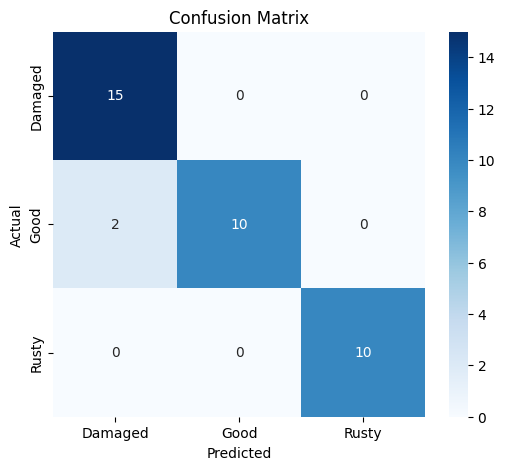

In [20]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

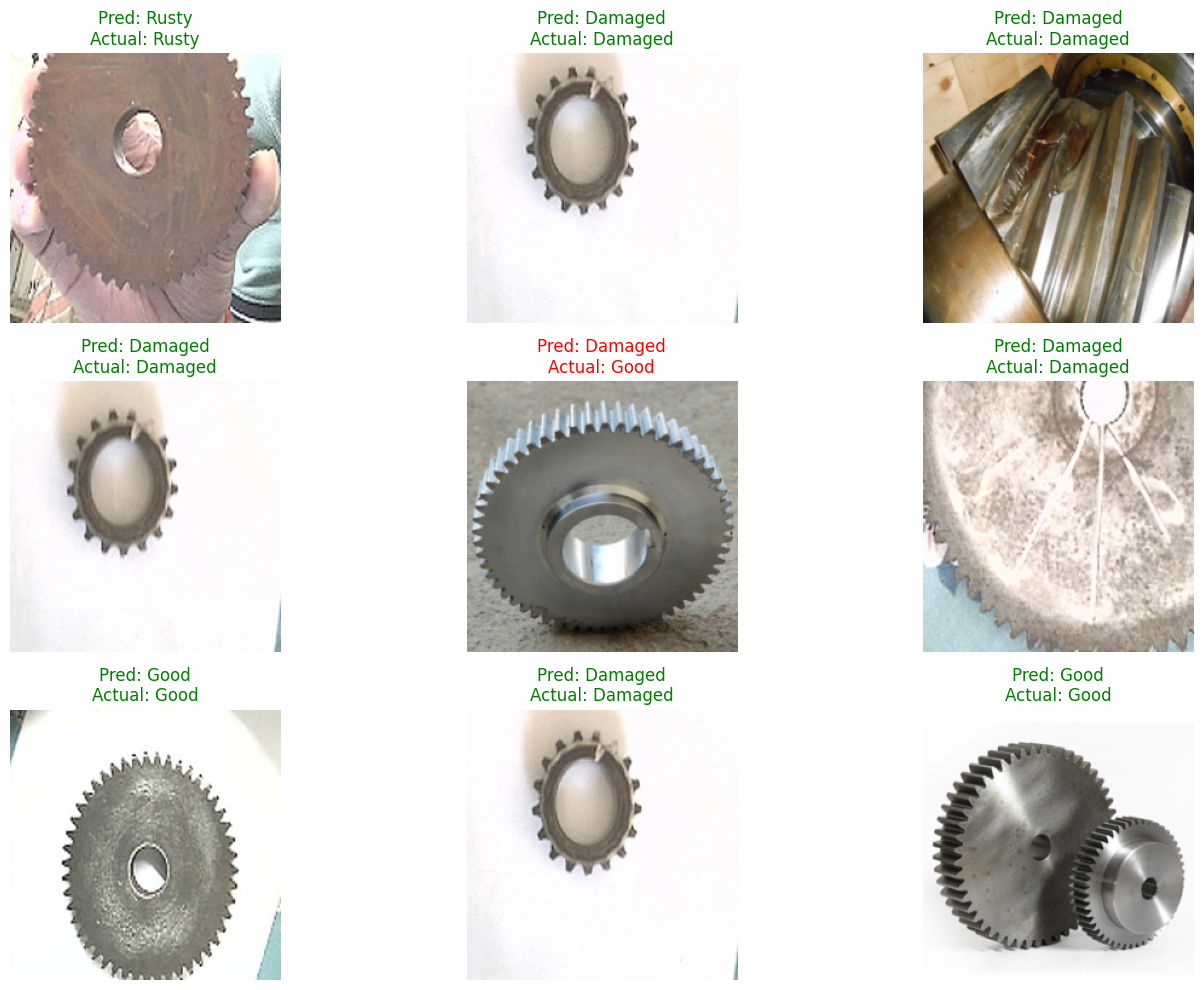

In [22]:
import random

fig = plt.figure(figsize=(15,10))

indices = random.sample(range(len(test_dataset)), 9)

for i, idx in enumerate(indices):

    image, label = test_dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(1).item()

    img = image.permute(1,2,0).numpy()

    img = img * [0.229,0.224,0.225] + [0.485,0.456,0.406]
    img = img.clip(0,1)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Pred: {class_names[pred]}\nActual: {class_names[label]}",
        color="green" if pred==label else "red"
    )

plt.tight_layout()
plt.show()